In [2]:
import sympy as sp
import numpy as np
import dg_geometry as DG503

D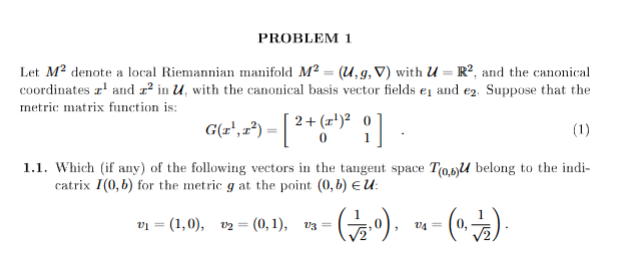

In [3]:
x1, x2, b = sp.symbols('x1 x2 b', real=True)

G = sp.Matrix([[2+x1**2, 0],[0, 1]])

G_0 = G.subs({x1: 0, x2: b})

v1 = sp.Matrix([1, 0])
v2 = sp.Matrix([0, 1])
v3 = sp.Matrix([1/sp.sqrt(2), 0])
v4 = sp.Matrix([0, 1/sp.sqrt(2)])

I1 = DG503.g_dot(G_0, v1, v1)
display(I1)
I2 = DG503.g_dot(G_0, v2, v2)
display(I2)
I3 = DG503.g_dot(G_0, v3, v3)
display(I3)
I4 = DG503.g_dot(G_0, v4, v4)
display(I4)


2

1

1

1/2

In [4]:
chris = DG503.christoffel_symbols(G, [x1, x2])
display(chris)

{(0, 0, 0): x1/(x1**2 + 2),
 (0, 0, 1): 0,
 (0, 1, 0): 0,
 (0, 1, 1): 0,
 (1, 0, 0): 0,
 (1, 0, 1): 0,
 (1, 1, 0): 0,
 (1, 1, 1): 0}

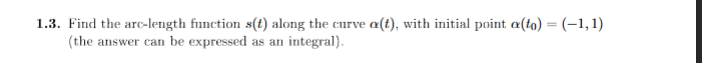

In [ ]:
t, s, tau = sp.symbols('t s tau', real=True)

alpha = sp.Matrix([[t], [1]])
alpha_dot = sp.diff(alpha, t)
G_alpha = G.subs(x1, alpha[0]).subs(x2, alpha[1])
display(G_alpha)

alpha_length = DG503.g_norm(G_alpha, alpha_dot)
display(alpha_length)

arc_length = sp.integrate(alpha_length.subs(t, tau), (tau, -1, t))
display(arc_length)

Matrix([
[t**2 + 2, 0],
[       0, 1]])

sqrt(t**2 + 2)

t*sqrt(t**2 + 2)/2 + asinh(sqrt(2)*t/2) + asinh(sqrt(2)/2) + sqrt(3)/2

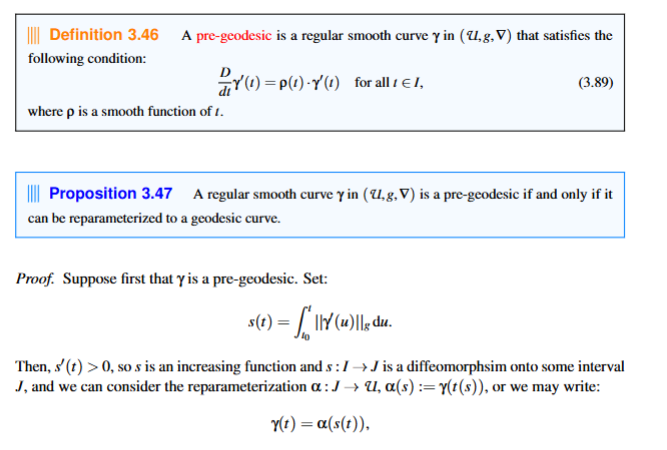

In [30]:
f  =sp.Function('f')(t)

alpha = sp.Matrix([[t], [1]])

alpha_dot = sp.diff(alpha, t)

alpha_ddot = DG503.curve_acceleration(G, alpha, t, [x1, x2])
display(alpha_ddot)

eq = sp.Eq(alpha_ddot, f*alpha_dot)
display(eq)

Matrix([
[t/(t**2 + 2)],
[           0]])

Eq(Matrix([
[t/(t**2 + 2)],
[           0]]), Matrix([
[f(t)],
[   0]]))

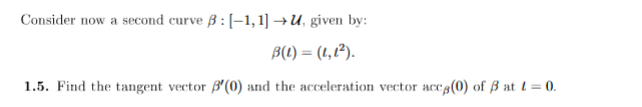

In [31]:
beta = sp.Matrix([[t], [t**2]])

beta_dot = sp.diff(beta, t)
display(beta_dot)

beta_dot_0 = beta_dot.subs(t, 0)
display(beta_dot_0)

beta_ddot = DG503.curve_acceleration(G, beta, t, [x1, x2])
display(beta_ddot)

beta_ddot_0 = beta_ddot.subs(t, 0)
display(beta_ddot_0)

Matrix([
[  1],
[2*t]])

Matrix([
[1],
[0]])

Matrix([
[t/(t**2 + 2)],
[           2]])

Matrix([
[0],
[2]])

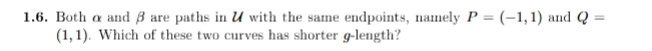

In [35]:
beta_length = sp.integrate(DG503.g_norm(G.subs(x1, beta[0]).subs(x2, beta[1]), beta_dot), (t, -1, 1))
display(sp.N(beta_length))

alpha_length = sp.integrate(DG503.g_norm(G.subs(x1, alpha[0]).subs(x2, alpha[1]), alpha_dot), (t, -1, 1))
display(sp.N(alpha_length))

3.75389683938573

3.04900870449369

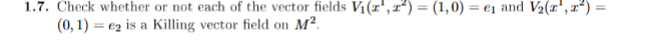

In [36]:
x1, x2 = sp.symbols('x1 x2', real=True)

coords = sp.Matrix([x1,x2])

V1 = sp.Matrix([1, 0])
V2 = sp.Matrix([0, 1])


Lv_g1 = DG503.lie_derivative_metric(G, V1, coords)
display(Lv_g1)

Lv_g2 = DG503.lie_derivative_metric(G, V2, coords)
display(Lv_g2)

Matrix([
[2*x1, 0],
[   0, 0]])

Matrix([
[0, 0],
[0, 0]])

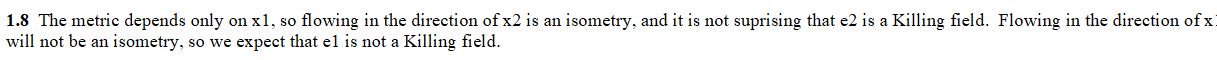

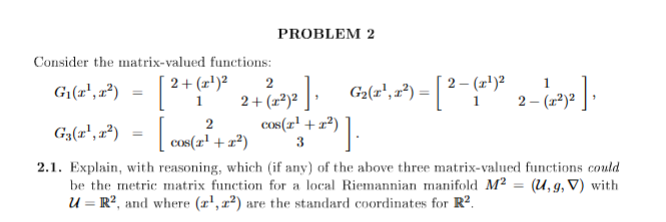

In [37]:
x1, x2 = sp.symbols('x1 x2', real=True)
G1 = sp.Matrix([[2 + x1**2, 2], [1, 2 + x2**2]])
G2 = sp.Matrix([[2 - x1**2, 1], [1, 2 - x2**2]])
G3 = sp.Matrix([[2, sp.cos(x1 + x2)], [sp.cos(x1 + x2), 3]])

print("G1 is symmetric",G1 == G1.T)
print("G2 is symmetric",G2 == G2.T)
print("G3 is symmetric",G3 == G3.T)

detG1 = G1.det()
detG2 = G2.det()
detG3 = G3.det()

print("Determinant of G1:", detG1)
print("Determinant of G2:", detG2)
print("Determinant of G3:", detG3)

G1 is symmetric False
G2 is symmetric True
G3 is symmetric True
Determinant of G1: x1**2*x2**2 + 2*x1**2 + 2*x2**2 + 2
Determinant of G2: x1**2*x2**2 - 2*x1**2 - 2*x2**2 + 3
Determinant of G3: 6 - cos(x1 + x2)**2


### Problem 2.1: Metric matrix check

- $G_1$ is not a valid metric matrix because it is not symmetric: the $(1,2)$ entry is $2$ while the $(2,1)$ entry is $1$.
- $G_2$ is symmetric and where it is positive definite. $\text{determinant} = (2 - (x^1)^2)(2 - (x^2)^2) - 1 > 0$.
 This is negative if $x^1$ and $x^2$ is more than $\sqrt2$ so it is not a local rimmenian manifold
- $G_3$ is symmetric and its determinant is $6 - \cos^2(x^1 + x^2)$. Since $\cos^2(\theta) \le 1$, the determinant is at least $5$, which is always positive. so it is local Riemannian Manifold.

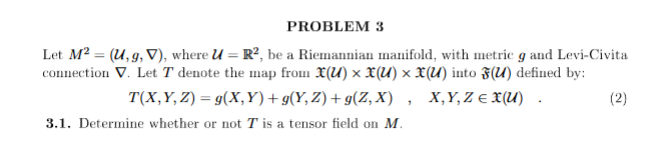

if you put in an f it will not come out so no

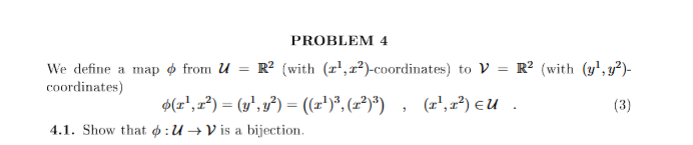

In [50]:

y1, y2, x1, x2 = sp.symbols('y1 y2 x1 x2', real=True)

phi = sp.Matrix([x1**3,x2**3])
display(phi)

J = phi.jacobian([x1, x2])
display(J)

det_J = J.det()
display(det_J)

# If sol is the result of solve
sol = sp.solve([sp.Eq(phi[0], y1), sp.Eq(phi[1], y2)], (x1, x2))

# Access the expressions using the symbols as keys
phi_inv = sp.Matrix([sol[0]]).T
display(phi_inv)

verification = phi_inv.subs({y1: phi[0], y2: phi[1]})

print("Verification (should result in [x1, x2]):")
display(sp.simplify(verification.doit()))

Matrix([
[x1**3],
[x2**3]])

Matrix([
[3*x1**2,       0],
[      0, 3*x2**2]])

9*x1**2*x2**2

Matrix([
[y1**(1/3)],
[y2**(1/3)]])

Verification (should result in [x1, x2]):


Matrix([
[(x1**3)**(1/3)],
[(x2**3)**(1/3)]])

In [55]:
phi_inv = sp.Matrix([sol[0]]).T
display(phi_inv)

J_inv = phi_inv.jacobian([y1, y2])
display(J_inv)

Matrix([
[y1**(1/3)],
[y2**(1/3)]])

Matrix([
[1/(3*y1**(2/3)),               0],
[              0, 1/(3*y2**(2/3))]])

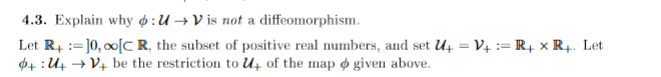

It can easily be seen that for all real numbers the jacobian is not defined as when y1 and y2 goes to 0

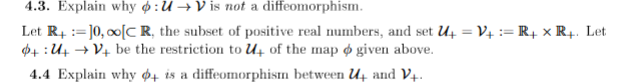

we can see if we only have a set of positive real numbers the jacobian is well defined

In [59]:
J_prod = J*J_inv
sp.simplify(J_prod.subs({y1:phi[0], y2:phi[1]})).doit()

Matrix([
[x1**2/(x1**3)**(2/3),                    0],
[                   0, x2**2/(x2**3)**(2/3)]])

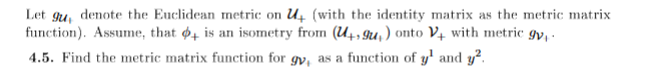

In [63]:
G_u = sp.eye(2)
display(G_u)

G_v = J_inv.T*G_u.subs({x1:phi_inv[0], x2:phi_inv[1]})*J_inv

display(G_v)

Matrix([
[1, 0],
[0, 1]])

Matrix([
[1/(9*y1**(4/3)),               0],
[              0, 1/(9*y2**(4/3))]])

In [66]:
a, b, c, d = sp.symbols('a b c d')

sec_curv = DG503.sectional_curvature(G_v, [y1,y2], [a,b], [c,d], [y1,y2])

display(sec_curv)

0

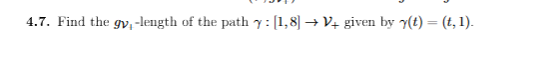

In [70]:
gamma = sp.Matrix([t, 1])

gamma_dot = gamma.diff(t)

gamma_length = sp.integrate(DG503.g_norm(G_v.subs(y1, gamma[0]).subs(y2, gamma[1]), gamma_dot), (t, 1, 8))
display(sp.N(gamma_length))


1.00000000000000